<a href="https://colab.research.google.com/github/SharvariSapte/Synapse/blob/main/Task1A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Synapse Week One**

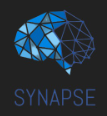

Last week, we focused on building the foundations needed to get started with Machine Learning. We explored Python and learned how to work with and understand data through Exploratory Data Analysis (EDA).

Now, it is time to take the next step and use that knowledge to build our first Machine Learning model. In this task, we will explore Regression, a type of supervised learning where the goal is to predict a continuous numerical value.

We will begin by exploring an insurance dataset and using EDA to understand the relationships between its different attributes and the insurance charges. Once we understand our data, we will prepare it for Machine Learning and build a Linear Regression model to predict the incurred charges.

But we won't stop at simply using a library. We will also take a look under the hood and implement Linear Regression from scratch, giving us a better understanding of what happens when a model is trained.

Resources and comments are provided throughout the notebook. Go through them carefully, understand the concepts, and then get coding.

Let's get started.

Supervised vs Unsupervised vs Reinforcement Learning:

https://www.simplilearn.com/tutorials/machine-learning-tutorial/types-of-machine-learning

Regression vs Classification :

https://www.analyticsvidhya.com/blog/2023/05/regression-vs-classification/ (Might be a little wordy)

https://www.youtube.com/watch?v=1NBwM5tavTk&ab_channel=IntuitiveML
(A very quick video)

https://www.geeksforgeeks.org/ml-classification-vs-regression/
(Short and Sweet)

Machine Learning for Everyone (Read till 1.1):

https://vas3k.com/blog/machine_learning/

Overfitting and Underfitting [VERY IMPORTANT]
https://www.youtube.com/watch?v=T9NtOa-IITo

Lets import all the basic libraries.

In [1]:
!pip install shap -q  #Will be used later on

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Regression

For regression we will use insurance dataset, which contains medical costs incurred
https://drive.google.com/file/d/1ld8fGZYBi5ytg8b1CcZJvPaXfhVzIhoZ/view?usp=sharing

## Basic EDA

### Import dataset

In [4]:
df = pd.read_csv('/content/drive/MyDrive/synapse/task1/insurance.csv')

### Use the very first steps involved in EDA -> info, head and describe

In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Now, plot a histogram to understand insurance charges *distribution*

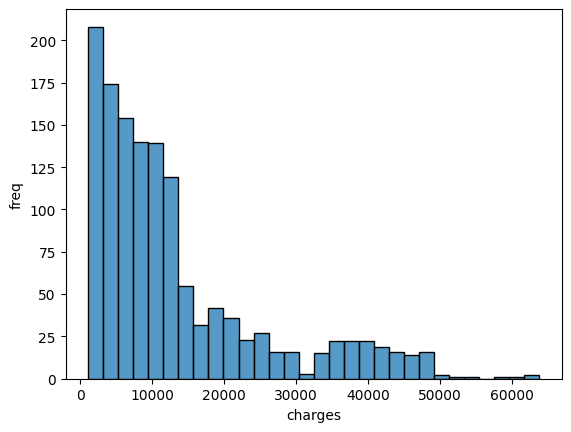

In [8]:
sb.histplot(data=df, x='charges')
plt.ylabel('freq')
plt.show()

### Plot a scatter plot between age and insurance charges

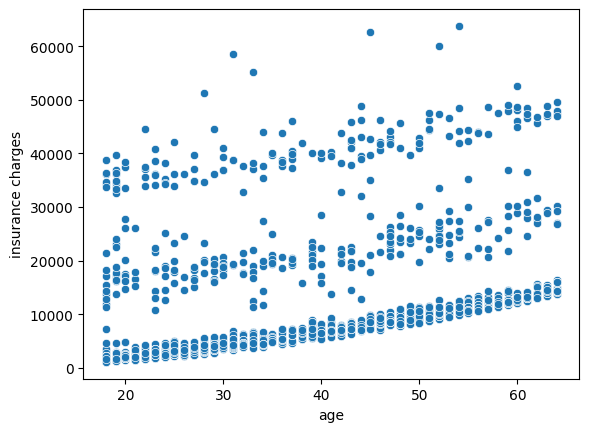

In [9]:
sb.scatterplot(data=df,x='age',y='charges')
plt.ylabel('insurance charges')
plt.show()

### Similarly, plot scatterplots for no. of children and charges, and also for bmi and charges


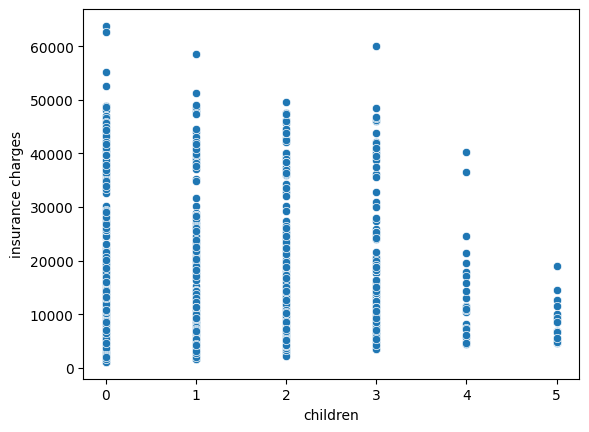

In [10]:
sb.scatterplot(data=df,x='children',y='charges')
plt.ylabel('insurance charges')
plt.show()

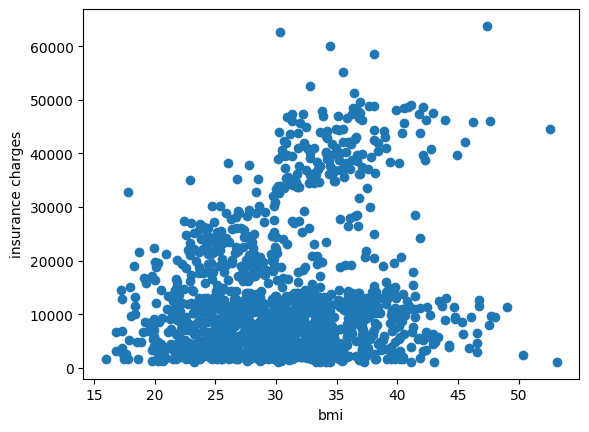

In [11]:
plt.scatter(df["bmi"],df["charges"])
plt.xlabel("bmi")
plt.ylabel("insurance charges")
plt.show()

### Now, use boxplots to find correlation between Sex and Charges, between Smoker and charges, and also between region and charges

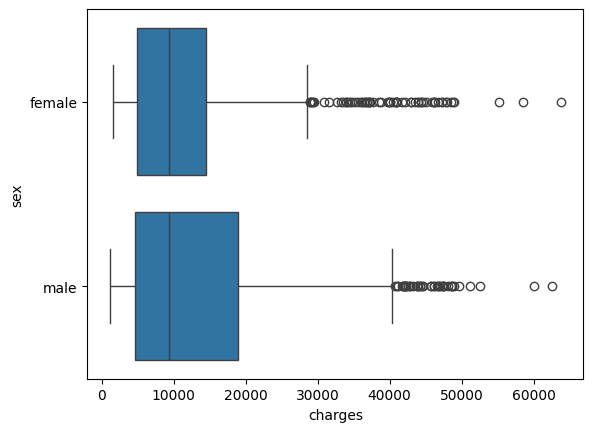

In [12]:
sb.boxplot(data=df,x='charges',y='sex')
plt.show()

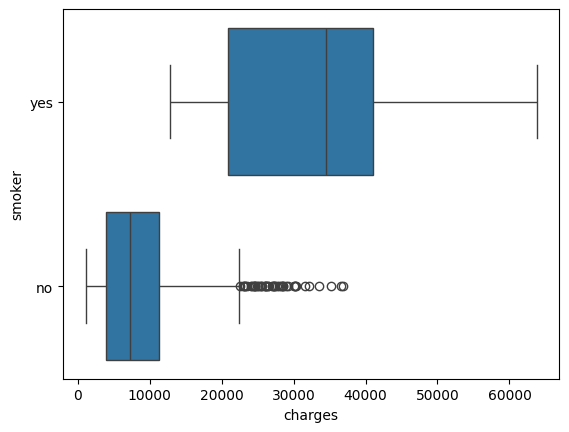

In [13]:
sb.boxplot(data=df,x='charges',y='smoker')
plt.show()

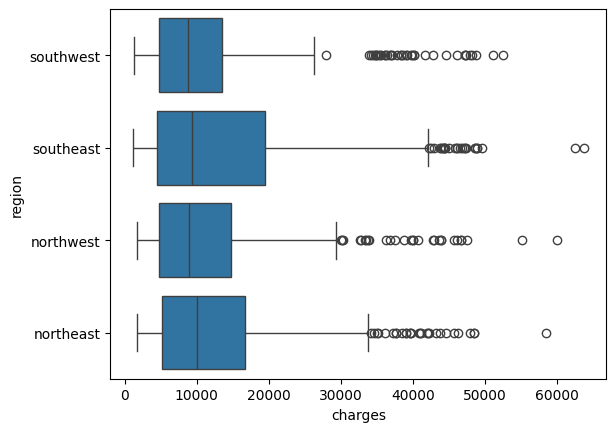

In [14]:
sb.boxplot(data=df,x='charges',y='region')
plt.show()

##### Now, make a heatmap to understand correlation between all attributes

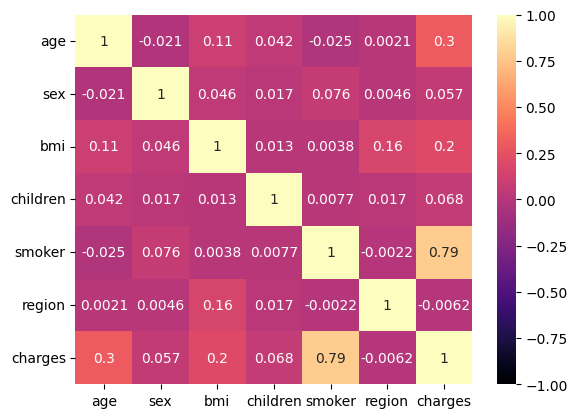

In [42]:
sb.heatmap(df.corr(numeric_only=True),annot=True, cmap='magma', vmin=-1, vmax=1)
plt.show()

## Question: What do you infer from the above analysis🤔

### Answer here:


### Now let's prep our data to perform Regression to predict the Incurred Charges

### Again do df.info() see how the datatype is

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### As you can see, sex, region and smoker attributes are of the object data type.
### So, convert them into numerical labels, using Label Encoder

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['region'] = le.fit_transform(df['region'])
df['smoker'] = le.fit_transform(df['smoker'])

Do df.head() to see how your dataframe looks like after LabelEncoding

In [19]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## Question: What does label encoder do? 🤔

The label encoder converts categorical data into numerical values by labeling them.
for instance when we use le.fit_transform() it learns the categories puts them into classes
then they are transformed into numerical labels

### Now that you already know about standardization and normalization (I hope🙃), implement normalization here here:


##### Import MinMaxScaler from sklearn and normalize the coloums - ['age','bmi', 'children', 'charges']



### Answer:

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['age','bmi','children','charges']] = scaler.fit_transform(df[['age','bmi','children','charges']])
df.head()

,age,sex,bmi,children,smoker,region,charges
0,0.021739,0,0.321227,0.0,1,3,0.251611
1,0.000000,1,0.479150,0.2,0,2,0.009636
2,0.217391,1,0.458434,0.6,0,2,0.053115
3,0.326087,1,0.181464,0.0,0,1,0.333010
4,0.304348,1,0.347592,0.0,0,1,0.043816


## Question: Why standardization is not needed here? 🤔



### Answer:
Normalization is scaling the values to a range so that no single feature gets a higher weightage just becuase its values are larger

standardization is when we scale values around the central value(mean) where the trandformed data gives mean = 0 and standard deviation =1. the transformed values show how far a value is from the mean in terms of standard deviation

so Here we wanted to scale features with very different ranges rather than scaling each of them wrt their central tendancy

As we are going to predict Insurance Charges, let us make two sections: one containing only the 'charges', and the other containing all values except for 'charges'

In [21]:
x= df.drop('charges', axis=1)
y = df['charges']
x.head()

,age,sex,bmi,children,smoker,region
0,0.021739,0,0.321227,0.0,1,3
1,0.000000,1,0.479150,0.2,0,2
2,0.217391,1,0.458434,0.6,0,2
3,0.326087,1,0.181464,0.0,0,1
4,0.304348,1,0.347592,0.0,0,1


### Train-Test Split

Implementation - https://www.youtube.com/watch?v=BUkqYGPnLZ8&ab_channel=ManifoldAILearning

### Now, while we need data to train our regression model, it is equally important to keep some data aside for testing the effectiveness of the aforementioned model. Thus the dataset as a whole is generally further divided into the training dataset and the testing dataset.

In order to implement this, import train_test_split function from scikit-learn.

In [22]:
from sklearn.model_selection import train_test_split

Print the size and shape of each of the train/test splits (it should be in the ratio as per test_size parameter above, i.e in ratio of 0.3)

In [23]:
X_train,X_test,y_train,y_test = train_test_split(x,y, test_size=0.3,random_state=1)

In [24]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(936, 6)
(402, 6)
(936,)
(402,)


### The data is now split into 2 datasets of size 70% and 30% of original dataset. Surprised? 😮

### We have preprocessed our DataFrame now we'll perform Regression on this Data

### First lets understand Linear Regression, watch this video carefully it will be helpfull later on :)

https://www.youtube.com/watch?v=7ArmBVF2dCs

### A quick article
https://www.analyticsvidhya.com/blog/2021/08/understanding-linear-regression-with-mathematical-insights/

In [25]:
#train a model
from sklearn.linear_model import LinearRegression

In [26]:
# fit the model on the training data, hint: use the fit method
regressor = LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

#### The X_train and y_train dataframes have been used to train the model. Now we will use X_test and y_test to evaluate the efficiency of the model we have trained.

#### Use regressor.predict() on X_test and store it in a variable called "y_pred". Print type and size of the y_pred.

#### Size should be 402 if everything is correct. Yeh line confirm karna hai

In [27]:
# make predictions on the test data
y_pred = regressor.predict(X_test)
print(y_pred.size)

402


In [28]:
# calculate the mean squared error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_pred)
print(f"{mse:4f}")

0.009375


### Visualize the predictions, plot a scatter plot of y_test vs y_pred and also plot the best fit line

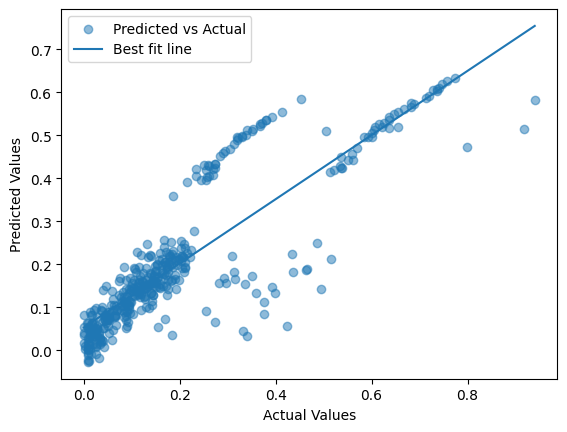

In [29]:
plt.scatter(y_test, y_pred, alpha=0.5, label="Predicted vs Actual")
m, b = np.polyfit(y_test, y_pred, 1)
x = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x, m * x + b, label="Best fit line")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()

# Now let's start the fun part 😃

### Have you ever wondered what happens when you call **'regressor.fit(X_train, y_train)'** ?

### To understand what's hapenning in .fit method we will be implementing Linear Regression from scratch.

In [30]:
class LinearRegression() :

    def __init__( self, learning_rate, iterations ) :
        # initialize the learning rate and iterations provides by the user
        self.learning_rate = learning_rate

        self.iterations = iterations

    # Function for model training
    def fit( self, X, Y ) :

        # no_of_training_examples, no_of_features
        self.m, self.n = X.shape

        # what does self.m and self.n represent and why are they calculated?
        # self.m represents the no. of rows (samples) in training data, while self.n shows number of features in the training data
        # they are calculated
        # weight initialization
        self.W = np.zeros(self.n)

        self.b = 0# set this equal to 0

        self.X = X # set this equal to X

        self.Y = Y# set this equal to Y


        # gradient descent learning
        for i in range(self.iterations) : # complete the range function

            self.update_weights()

        return self

    # Helper function to update weights in gradient descent
    def update_weights(self) :

        Y_pred = self.predict(self.X)# complete this line

        # calculate gradients
        dW = - (2 * (self.X.T).dot(self.Y - Y_pred)) / self.m # dL/dW -> L = MSE = (y -ypred)^2/m
        db = - 2 * np.sum(self.Y - Y_pred) / self.m

        # write the code to update the weights
        self.W -= self.learning_rate*dW
        self.b -= self.learning_rate*db

        return self


    def predict(self,X) :

        return X.dot(self.W) + self.b


In [31]:
model = LinearRegression( iterations = 10000, learning_rate = 0.0015 )

model.fit(X_train, y_train)


## Question: What is this function actually doing? 🤔
#### Answer Here
<br>

### Now predict the output for the test data

In [32]:
y_pred = model.predict(X_test)
print(y_pred.size)

402


### Calculate the mean squared error


In [33]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test,y_pred)
print(f"{mse:4f}")

0.009844


### Plot a similar scatter plot as above


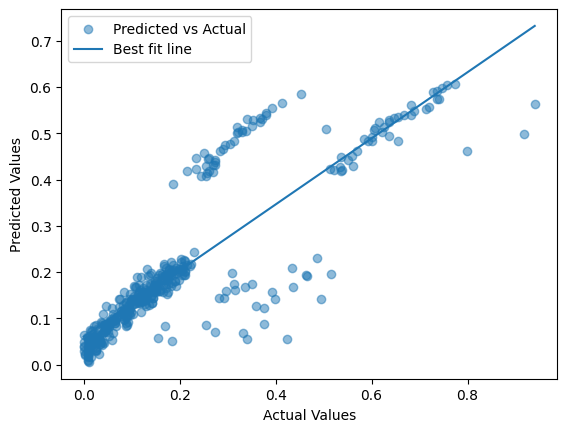

In [34]:
plt.scatter(y_test, y_pred, alpha=0.5, label="Predicted vs Actual")
m, b = np.polyfit(y_test, y_pred, 1)
x = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x, m * x + b, label="Best fit line")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.legend()
plt.show()

How to Approach the Research Tasks :)

Guys, one important thing about how you should approach these tasks.

The links and videos provided are meant to be read/watched. Go through them, understand the concepts, and then write what you understood in your own words. You can also find your own resources — don't restrict yourself to the links we provide.

And please, don’t just GPT your way through the tasks. These are your foundational basics, so actually understand what you're doing. Try reading documentation, Stack Overflow discussions, technical articles, etc. These will become your best guides when you're learning ML independently.

The Research Task is compulsory and one of the most important parts of your learning, irrespective of what you do. Research is an engineer's way of learning — it's how you learn ML for what it actually is, rather than just learning how to write the code.

For the Research Task, research properly, understand what you find, and explain it in your own words. No implementation is required unless mentioned.

The best Research Task submission after every task will be featured on Synapse's LinkedIn with a tag, giving you an opportunity to connect with our alumni and seniors and grow your network.

So don't treat the Research Task as just another question to finish. Actually explore, understand, and learn from it :)

## Research Task: Underfitting & Overfitting

We’ve now built our first Linear Regression model. Before moving ahead, let’s understand an important problem that can affect any ML model: **Underfitting and Overfitting**.

### Resources

Read/watch the following:

* [SuperAnnotate — Overfitting & Underfitting](https://www.superannotate.com/blog/overfitting-and-underfitting-in-machine-learning) — simple theory and intuition
* [GreyAtom — Underfitting & Overfitting](https://medium.com/greyatom/what-is-underfitting-and-overfitting-in-machine-learning-and-how-to-deal-with-it-6803a989c76) — includes mathematical intuition
* [2-minute video](https://youtu.be/pptU3bpJojo?si=1uZ4yO_OQGkvEym-) — quick visual explanation

You can also find your **own resources** if you want to understand something better.

### Your Task

After going through the resources, write **what you understood in your own words**.

Make sure you can explain:

* What is underfitting?
* What is overfitting?
* What are **bias and variance**, and how are they related to underfitting and overfitting?
* How can you identify whether a model is underfitting or overfitting?
* Mention at least **one way to deal with each**.

You don't need to copy definitions from the resources. The goal is to see whether **you actually understand the concept and can explain it yourself**.

**No implementation is required.** Focus on understanding the concepts and explaining them clearly.

*Good Luck People :)*


End of Task

©DJS Synapse 2026 - 2027